# Native DreamLens: Reproducible ResNet18 Gallery

This notebook directly reproduces the tested result style in `results/native_dreamlens_notebook/`. It is self-contained: every optimization, input-preparation step, gallery layout, comparison panel, contact sheet, manifest, and validation runs in notebook cells. It does **not** call an external runner script.

The notebook contains two practical workflows:

1. **Batched channel visualization** — render six channels from an intermediate layer in one optimization batch.
2. **Image caricature** — amplify features from a real input image using a deeper ResNet18 layer.

Run the cells from top to bottom. The final cell verifies every expected file and confirms that the model weights did not change.

## Why these settings produce the intended results

The quality and visual style come from keeping the working reference configuration intact:

| Setting | Used here | Why it matters |
| --- | --- | --- |
| Canvas | `RenderConfig.reference()` | Uses the tested FFT-backed reference image parameterization. |
| Channel objective | `reduction="norm"` | Produces strong spatial channel patterns in a short run. |
| Render size | 160×160 | Gives enough detail without making CPU execution excessive. |
| Channel rendering | `maximize_channels()` | Optimizes one image per requested channel as a batch. |
| Caricature config | `AmplifyConfig.reference()` | Starts from Fourier noise and amplifies the input's feature direction. |
| Randomness | Fixed seed per workflow | Makes repeated CPU runs reproducible. |

An activation atlas answers a different question and does not produce this gallery style, so it is intentionally not mixed into these result panels.

## 1. Install and import

Install the project and example dependencies once from the repository root:

```bash
pip install -e ".[examples]"
```

The first run may download the pretrained ResNet18 weights and two demonstration images. Deterministic fallback images are created if an image download fails.

In [1]:
import json
import os
import random
import sys
import urllib.request
from pathlib import Path

import numpy as np
import torch
from IPython.display import display
from PIL import Image, ImageDraw, ImageOps


def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents, start / "activation-atlas-pytorch"]
    for candidate in candidates:
        if (candidate / "src" / "dreamlens").is_dir():
            return candidate
    raise RuntimeError(
        "Could not find src/dreamlens. Run this notebook from the repository "
        "root or the examples directory."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
os.environ.setdefault("TORCH_HOME", str(PROJECT_ROOT / ".torch-cache"))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from torchvision import models
from torchvision.models import ResNet18_Weights

from dreamlens import (
    AmplifyConfig,
    FeatureVisualizer,
    RenderConfig,
    TransformConfig,
)

## 2. Reproducible configuration

These values match the tested artifacts currently stored in `results/native_dreamlens_notebook/`. CPU is used deliberately for stable reproduction across machines; change `DEVICE` to `"cuda"` for a faster, but not necessarily pixel-identical, run.

In [2]:
SEED = 123
SIZE = 160
STEPS = 42
CARICATURE_SIZE = 160
CARICATURE_STEPS = 45
DEVICE = torch.device("cpu")

OUTPUT_DIR = PROJECT_ROOT / "results" / "native_dreamlens_notebook"
IMAGE_DIR = OUTPUT_DIR / "images"
INPUT_DIR = OUTPUT_DIR / "inputs"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
INPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_SOURCES = {
    "dog": "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    "street": "https://raw.githubusercontent.com/pytorch/hub/master/images/deeplab1.png",
}

CHANNEL_WORKFLOWS = [
    {
        "name": "resnet18_layer2_channels",
        "layer": "layer2.1.conv2",
        "channels": [3, 17, 41, 64, 89, 121],
    },
    {
        "name": "resnet18_layer4_channels",
        "layer": "layer4.1.conv2",
        "channels": [7, 53, 119, 211, 337, 451],
    },
]

CARICATURE_WORKFLOWS = [
    {
        "name": "dog_layer3_caricature",
        "input": "dog",
        "layer": "layer3.1.conv2",
        "power": 1.15,
    },
    {
        "name": "street_layer4_caricature",
        "input": "street",
        "layer": "layer4.1.conv2",
        "power": 1.10,
    },
]

print(f"Project: {PROJECT_ROOT}")
print(f"Device:  {DEVICE}")
print(f"Output:  {OUTPUT_DIR}")

Project: /Users/susmered/Documents/arena/activation-atlas-pytorch
Device:  cpu
Output:  /Users/susmered/Documents/arena/activation-atlas-pytorch/results/native_dreamlens_notebook


## 3. Small reproducibility and layout helpers

Optimization produces individual images. These helpers seed all random generators, prepare inputs, and compose labeled sheets without hiding any rendering logic.

In [3]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_fallback_image(name, path, size):
    image = Image.new("RGB", (size, size), (232, 236, 230))
    draw = ImageDraw.Draw(image)
    if name == "street":
        draw.rectangle((0, size * 0.55, size, size), fill=(68, 72, 82))
        draw.polygon(
            [(0, size * 0.55), (size * 0.5, size * 0.2), (size, size * 0.55)],
            fill=(190, 204, 222),
        )
        for x in range(20, size, 48):
            draw.rectangle(
                (x, size * 0.38, x + 24, size * 0.75),
                fill=(110, 130, 150),
            )
    else:
        draw.ellipse(
            (size * 0.18, size * 0.16, size * 0.82, size * 0.78),
            fill=(190, 126, 76),
        )
        draw.ellipse(
            (size * 0.30, size * 0.30, size * 0.42, size * 0.42),
            fill=(30, 35, 40),
        )
        draw.ellipse(
            (size * 0.58, size * 0.30, size * 0.70, size * 0.42),
            fill=(30, 35, 40),
        )
        draw.rectangle(
            (size * 0.43, size * 0.50, size * 0.57, size * 0.58),
            fill=(55, 42, 36),
        )
    image.save(path)


def prepare_inputs(input_dir, size):
    outputs = {}
    for name, url in INPUT_SOURCES.items():
        raw_path = input_dir / f"{name}_raw.png"
        square_path = input_dir / f"{name}_{size}.png"
        if not raw_path.exists():
            try:
                urllib.request.urlretrieve(url, raw_path)
            except Exception as error:
                print(f"Could not download {name} ({error}); using fallback.")
                make_fallback_image(name, raw_path, size=max(size, 224))
        image = Image.open(raw_path).convert("RGB")
        image = ImageOps.fit(
            image,
            (size, size),
            method=Image.Resampling.LANCZOS,
        )
        image.save(square_path)
        outputs[name] = square_path
    return outputs


def image_shape(path):
    with Image.open(path) as image:
        return [image.height, image.width, len(image.getbands())]

In [4]:
def make_labeled_sheet(paths, output_path, channels, title, columns=3, padding=36):
    images = [Image.open(path).convert("RGB") for path in paths]
    tile_width, tile_height = images[0].size
    rows = int(np.ceil(len(images) / columns))
    title_height = 72
    label_height = 28
    sheet = Image.new(
        "RGB",
        (
            columns * tile_width + (columns + 1) * padding,
            title_height
            + rows * (tile_height + label_height)
            + (rows + 1) * padding,
        ),
        (255, 255, 255),
    )
    draw = ImageDraw.Draw(sheet)
    for index, line in enumerate(title.splitlines()):
        box = draw.textbbox((0, 0), line)
        x = (sheet.width - (box[2] - box[0])) // 2
        draw.text((x, 10 + index * 24), line, fill=(0, 0, 0))
    for index, image in enumerate(images):
        row, column = divmod(index, columns)
        x = padding + column * (tile_width + padding)
        y = title_height + padding + row * (tile_height + label_height + padding)
        label = f"channel:{channels[index]}"
        box = draw.textbbox((0, 0), label)
        label_x = x + (tile_width - (box[2] - box[0])) // 2
        draw.text((label_x, y), label, fill=(0, 0, 0))
        sheet.paste(image, (x, y + label_height))
    sheet.save(output_path)


def make_comparison_panel(paths, output_path, labels, title, padding=24):
    images = [Image.open(path).convert("RGB") for path in paths]
    tile_width, tile_height = images[0].size
    title_height = 40
    label_height = 24
    width = len(images) * tile_width + (len(images) + 1) * padding
    height = title_height + label_height + tile_height + padding * 2
    panel = Image.new("RGB", (width, height), (255, 255, 255))
    draw = ImageDraw.Draw(panel)
    box = draw.textbbox((0, 0), title)
    draw.text(((width - (box[2] - box[0])) // 2, 10), title, fill=(0, 0, 0))
    for index, image in enumerate(images):
        x = padding + index * (tile_width + padding)
        y = title_height + label_height
        label = labels[index]
        box = draw.textbbox((0, 0), label)
        label_x = x + (tile_width - (box[2] - box[0])) // 2
        draw.text((label_x, title_height), label, fill=(0, 0, 0))
        panel.paste(image, (x, y))
    panel.save(output_path)


def fit_tile(image, tile_size):
    image.thumbnail((tile_size, tile_size), Image.Resampling.LANCZOS)
    tile = Image.new("RGB", (tile_size, tile_size), (245, 245, 245))
    tile.paste(
        image,
        ((tile_size - image.width) // 2, (tile_size - image.height) // 2),
    )
    return tile


def make_contact_sheet(paths, output_path, columns=1, tile_size=420, padding=8):
    paths = list(paths)
    tiles = [
        fit_tile(Image.open(path).convert("RGB"), tile_size)
        for path in paths
    ]
    rows = int(np.ceil(len(tiles) / columns))
    canvas = Image.new(
        "RGB",
        (
            columns * tile_size + (columns + 1) * padding,
            rows * tile_size + (rows + 1) * padding,
        ),
        (245, 245, 245),
    )
    for index, tile in enumerate(tiles):
        row, column = divmod(index, columns)
        x = padding + column * (tile_size + padding)
        y = padding + row * (tile_size + padding)
        canvas.paste(tile, (x, y))
    canvas.save(output_path)

## 4. Load ResNet18 and build the reference render configuration

The visualizer moves the model to the selected device and leaves it in evaluation mode. The reference configuration uses the same transforms for both channel galleries.

In [5]:
set_seed(SEED)
model = models.resnet18(weights=ResNet18_Weights.DEFAULT).eval()
visualizer = FeatureVisualizer(
    model,
    device=DEVICE,
    normalize=True,
    quiet=True,
)

render_config = RenderConfig.reference(
    width=SIZE,
    height=SIZE,
    steps=STEPS,
    lr=9e-3,
    weight_decay=0.0,
    grad_clip=1.0,
    transform=TransformConfig(
        rotate_degrees=10,
        scale_min=0.7,
        scale_max=1.15,
        translate_x=0.02,
        translate_y=0.02,
    ),
)


def parameter_checksum(module):
    return tuple(
        (float(p.detach().sum()), float(p.detach().square().sum()))
        for p in module.parameters()
    )


MODEL_CHECKSUM = parameter_checksum(model)
print(model.__class__.__name__)
print(render_config)

ResNet
RenderConfig(width=160, height=160, steps=42, lr=0.009, weight_decay=0.0, grad_clip=1.0, transform=TransformConfig(rotate_degrees=10, scale_min=0.7, scale_max=1.15, translate_x=0.02, translate_y=0.02, transforms=None), preprocess=None, optimizer_cls=None, fft=True, decorrelate=True, attempts=1, noise_std=0.01, parameterization='reference')


### What a channel means

A convolutional layer returns `[batch, channels, height, width]`. `maximize_channels()` creates one trainable canvas for each requested channel and optimizes all six canvases together. `reduction="norm"` converts each channel's spatial activation grid into one strong objective value.

In [6]:
probe = torch.zeros(1, 3, SIZE, SIZE)
captured = visualizer.capture_layers(
    [workflow["layer"] for workflow in CHANNEL_WORKFLOWS],
    probe,
    first_batch=False,
)
for workflow, output in zip(CHANNEL_WORKFLOWS, captured):
    print(f"{workflow['layer']:18s} -> {tuple(output.shape)}")
    assert max(workflow["channels"]) < output.shape[1]

layer2.1.conv2     -> (1, 128, 20, 20)
layer4.1.conv2     -> (1, 512, 5, 5)


## 5. Prepare inputs and the result manifest

The manifest records the model, seeds, layers, channels, inputs, and every generated output.

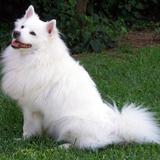

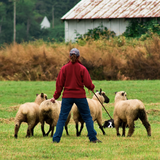

In [7]:
inputs = prepare_inputs(INPUT_DIR, CARICATURE_SIZE)
manifest = {
    "native_dreamlens_only": True,
    "purpose": "Notebook result set using different images and ResNet18 layers.",
    "model": "torchvision.models.resnet18",
    "weights": "ResNet18_Weights.DEFAULT",
    "device": str(DEVICE),
    "seed": SEED,
    "size": SIZE,
    "steps": STEPS,
    "caricature_size": CARICATURE_SIZE,
    "caricature_steps": CARICATURE_STEPS,
    "inputs": {
        name: str(path.relative_to(OUTPUT_DIR))
        for name, path in inputs.items()
    },
    "workflows": [],
}

display(Image.open(inputs["dog"]))
display(Image.open(inputs["street"]))

# Workflow 1 — Batched channel galleries

The function below contains the complete channel workflow: resolve the layer, optimize six reference canvases, save every image, build a labeled 3×2 sheet, and add the files to the manifest.

In [8]:
def run_channel_workflow(workflow, seed):
    set_seed(seed)
    layer = model.get_submodule(workflow["layer"])
    channels = workflow["channels"]
    result = visualizer.maximize_channels(
        layer=layer,
        channels=channels,
        reduction="norm",
        config=render_config,
    )

    item_paths = []
    for index, channel in enumerate(channels):
        path = IMAGE_DIR / f"{workflow['name']}_channel_{channel}.png"
        result.image[index].save(path)
        item_paths.append(path)

    sheet_path = IMAGE_DIR / f"{workflow['name']}.png"
    make_labeled_sheet(
        item_paths,
        sheet_path,
        channels=channels,
        title=f"model: resnet18\nlayer: {workflow['layer']}",
        columns=3,
    )
    manifest["workflows"].append(
        {
            "name": workflow["name"],
            "type": "batched_channel_render",
            "layer": workflow["layer"],
            "channels": channels,
            "output": str(sheet_path.relative_to(OUTPUT_DIR)),
            "shape": image_shape(sheet_path),
            "items": [
                {
                    "channel": channel,
                    "output": str(item_paths[index].relative_to(OUTPUT_DIR)),
                    "shape": image_shape(item_paths[index]),
                }
                for index, channel in enumerate(channels)
            ],
        }
    )
    return result, sheet_path

Final loss: -117.5233


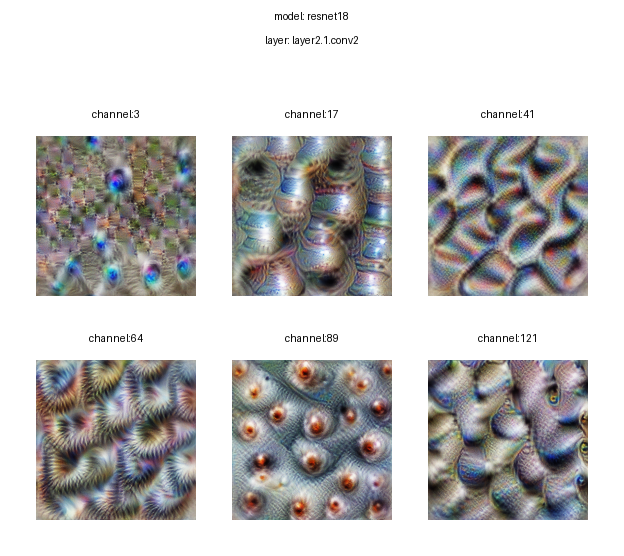

In [9]:
layer2_result, layer2_sheet = run_channel_workflow(
    CHANNEL_WORKFLOWS[0],
    seed=SEED + 10,
)
print(f"Final loss: {layer2_result.objective_value:.4f}")
display(Image.open(layer2_sheet))

Final loss: -43.9705


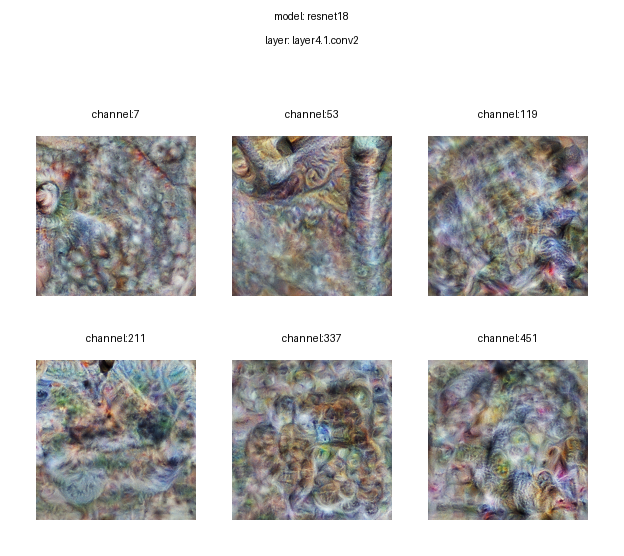

In [10]:
layer4_result, layer4_sheet = run_channel_workflow(
    CHANNEL_WORKFLOWS[1],
    seed=SEED + 11,
)
print(f"Final loss: {layer4_result.objective_value:.4f}")
display(Image.open(layer4_sheet))

# Workflow 2 — Reference feature caricatures

`caricature()` first captures the selected layer's activations from the input image. A separate FFT-backed reference canvas starts from noise and is optimized to point in the same feature direction with stronger magnitude. The input image is never modified.

The deeper `layer3.1.conv2` and `layer4.1.conv2` features produce the semantic, dream-like results shown in the existing result directory.

In [11]:
def run_caricature_workflow(workflow, seed):
    set_seed(seed)
    input_path = inputs[workflow["input"]]
    source = Image.open(input_path).convert("RGB")
    layer = model.get_submodule(workflow["layer"])

    result = visualizer.caricature(
        image=source,
        layers=[layer],
        power=workflow["power"],
        config=AmplifyConfig.reference(
            steps=CARICATURE_STEPS,
            lr=9e-3,
        ),
    )

    output_path = IMAGE_DIR / f"{workflow['name']}_output.png"
    result.save(output_path)
    panel_path = IMAGE_DIR / f"{workflow['name']}.png"
    make_comparison_panel(
        [input_path, output_path],
        panel_path,
        labels=[workflow["input"], workflow["layer"]],
        title=f"native DreamLens caricature: {workflow['name']}",
    )
    manifest["workflows"].append(
        {
            "name": workflow["name"],
            "type": "caricature",
            "input": str(input_path.relative_to(OUTPUT_DIR)),
            "layer": workflow["layer"],
            "power": workflow["power"],
            "steps": CARICATURE_STEPS,
            "output": str(panel_path.relative_to(OUTPUT_DIR)),
            "caricature": str(output_path.relative_to(OUTPUT_DIR)),
            "shape": image_shape(panel_path),
        }
    )
    return result, panel_path

Final loss: -838351.0625


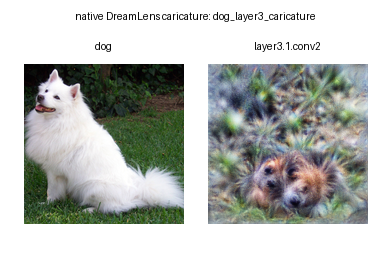

In [12]:
dog_result, dog_panel = run_caricature_workflow(
    CARICATURE_WORKFLOWS[0],
    seed=SEED + 100,
)
print(f"Final loss: {dog_result.objective_value:.4f}")
display(Image.open(dog_panel))

Final loss: -4605.1479


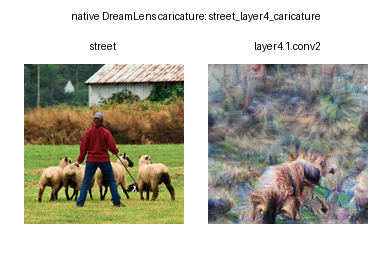

In [13]:
street_result, street_panel = run_caricature_workflow(
    CARICATURE_WORKFLOWS[1],
    seed=SEED + 101,
)
print(f"Final loss: {street_result.objective_value:.4f}")
display(Image.open(street_panel))

## 6. Build the contact sheet and write the manifest

The contact sheet combines the two channel galleries and two caricature panels into one review image.

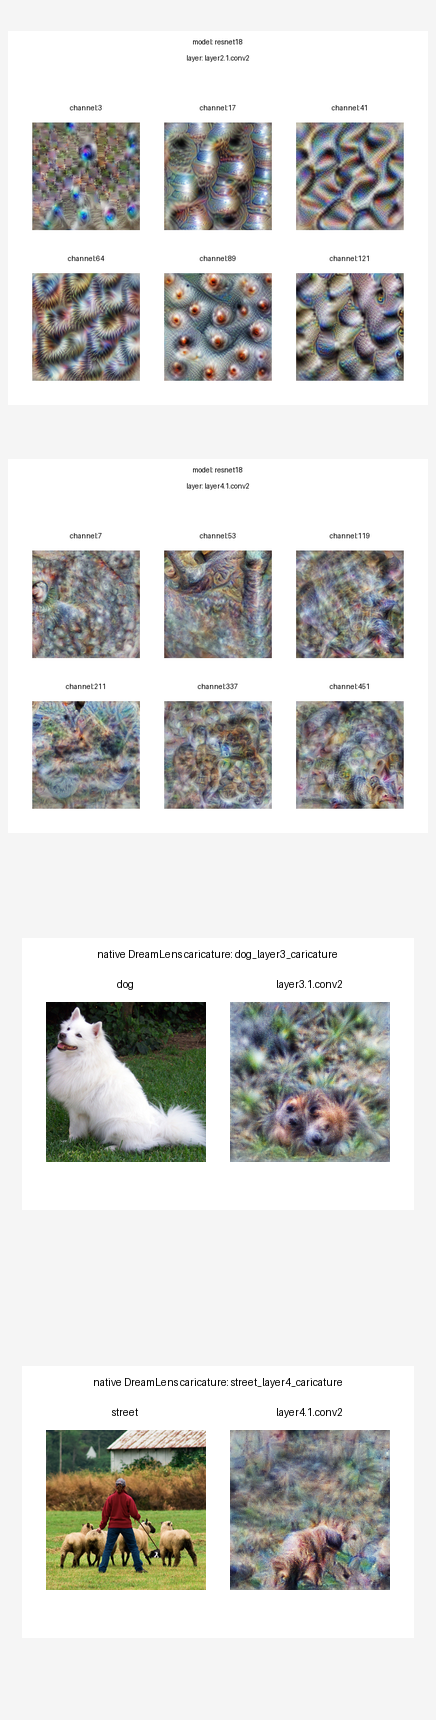

In [14]:
contact_sheet_path = OUTPUT_DIR / "native_notebook_contact_sheet.png"
make_contact_sheet(
    [OUTPUT_DIR / item["output"] for item in manifest["workflows"]],
    contact_sheet_path,
    columns=1,
    tile_size=420,
)
manifest["contact_sheet"] = contact_sheet_path.name
manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.write_text(
    json.dumps(manifest, indent=2) + "\n",
    encoding="utf-8",
)
display(Image.open(contact_sheet_path))

### Expected gallery

The generated contact sheet remains visible when this output-free notebook is viewed on GitHub:

![Native DreamLens channel galleries and caricatures](../results/native_dreamlens_notebook/native_notebook_contact_sheet.png)

## 7. Validate the complete result set

This cell checks workflow count, output dimensions, finite losses, file existence, and model-weight integrity. If it completes, the notebook produced the expected result set.

In [15]:
assert len(manifest["workflows"]) == 4
assert len(layer2_result.losses) == STEPS
assert len(layer4_result.losses) == STEPS
assert len(dog_result.losses) == CARICATURE_STEPS
assert len(street_result.losses) == CARICATURE_STEPS
assert np.isfinite(layer2_result.losses).all()
assert np.isfinite(layer4_result.losses).all()
assert np.isfinite(dog_result.losses).all()
assert np.isfinite(street_result.losses).all()
assert parameter_checksum(model) == MODEL_CHECKSUM

for workflow in manifest["workflows"]:
    output_path = OUTPUT_DIR / workflow["output"]
    assert output_path.exists(), output_path
    assert image_shape(output_path) == workflow["shape"]
    print(
        f"{workflow['name']:32s} "
        f"{workflow['shape']} -> {workflow['output']}"
    )

assert image_shape(layer2_sheet) == [556, 624, 3]
assert image_shape(layer4_sheet) == [556, 624, 3]
assert image_shape(dog_panel) == [272, 392, 3]
assert image_shape(street_panel) == [272, 392, 3]
assert contact_sheet_path.exists()
assert manifest_path.exists()

print("\nAll checks passed. Model weights are unchanged.")
print(f"Results: {OUTPUT_DIR}")

resnet18_layer2_channels         [556, 624, 3] -> images/resnet18_layer2_channels.png
resnet18_layer4_channels         [556, 624, 3] -> images/resnet18_layer4_channels.png
dog_layer3_caricature            [272, 392, 3] -> images/dog_layer3_caricature.png
street_layer4_caricature         [272, 392, 3] -> images/street_layer4_caricature.png

All checks passed. Model weights are unchanged.
Results: /Users/susmered/Documents/arena/activation-atlas-pytorch/results/native_dreamlens_notebook


## Adapting the notebook

- Change a channel list only after checking the selected layer's channel count.
- Increase `STEPS` for more detail; reduce it only for quick smoke checks.
- Replace an input URL or point `inputs[...]` at a local image.
- Use earlier layers for textures and deeper layers for more semantic patterns.
- Keep `RenderConfig.reference()` and `AmplifyConfig.reference()` when you want this result style.